## Loading Data
Loading data from the data preprocessing step

In [16]:
from pathlib import Path
from pyspark.sql import SparkSession

import os
import sys

python_exe = sys.executable
os.environ["PYSPARK_PYTHON"] = python_exe
os.environ["PYSPARK_DRIVER_PYTHON"] = python_exe

spark = (
    SparkSession.builder
    .appName("EEG_Schizoprenia")
    .master("local[2]")                  # avoid local[*] for heavy tuning
    .config("spark.pyspark.python", python_exe)
    .config("spark.pyspark.driver.python", python_exe)
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.memory", "6g") # raise this
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

sc = spark.sparkContext
print("Spark started:", spark.version)
print("Python:", sc.pythonExec)

Spark started: 4.0.0
Python: C:\Users\Joy Anne\anaconda3\envs\DSAI4202\python.exe


In [17]:
from pathlib import Path

from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.classification import LinearSVC

project_root = Path("").resolve()

input_path = project_root / "data" / "processed" / "pca_final_modeling_table"

df = spark.read.parquet(str(input_path))

## Splitting the Dataframe to Train, Validation, and Test

To avoid data leakage when training the model, the data is split by subjects/participants. Although the subject is not part of the feature column, we still separate the train, validation, and test sets to ensure there is no overlap of subjects. In other words, no participant appears in more than one split.

In [18]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

subject_df = df.groupBy("subject").agg(F.first("label").alias("label"))

# split by subjects to avoid data leakage
# create an approximate 70/15/15 split within each label group
split_window = Window.partitionBy("label").orderBy(F.rand(seed=4202))
count_window = Window.partitionBy("label")

subject_splits = (
    subject_df
    .withColumn("row_num", F.row_number().over(split_window))
    .withColumn("label_count", F.count("*").over(count_window))
    .withColumn("train_size", F.floor(F.col("label_count") * F.lit(0.70)))
    .withColumn("val_size", F.floor(F.col("label_count") * F.lit(0.15)))
    .withColumn(
        "split",
        F.when(F.col("row_num") <= F.col("train_size"), F.lit("train"))
         .when(F.col("row_num") <= F.col("train_size") + F.col("val_size"), F.lit("val"))
         .otherwise(F.lit("test"))
    )
)

train_subjects = subject_splits.filter(F.col("split") == "train").select("subject", "label")
val_subjects = subject_splits.filter(F.col("split") == "val").select("subject", "label")
test_subjects = subject_splits.filter(F.col("split") == "test").select("subject", "label")

train_df = df.join(train_subjects.select("subject"), on="subject", how="inner")
val_df = df.join(val_subjects.select("subject"), on="subject", how="inner")
test_df = df.join(test_subjects.select("subject"), on="subject", how="inner")

In [19]:
train_subject_list = [int(row["subject"]) for row in train_subjects.orderBy("subject").select("subject").collect()]
val_subject_list = [int(row["subject"]) for row in val_subjects.orderBy("subject").select("subject").collect()]
test_subject_list = [int(row["subject"]) for row in test_subjects.orderBy("subject").select("subject").collect()]

print("Train Subjects:", train_subject_list)
print("Validation Subjects:", val_subject_list)
print("Test Subjects:", test_subject_list)

# confirm no overlap of subjects
print("Train/Validation overlap:", len(set(train_subject_list) & set(val_subject_list)))
print("Train/Test overlap:", len(set(train_subject_list) & set(test_subject_list)))
print("Validation/Test overlap:", len(set(val_subject_list) & set(test_subject_list)))


Train Subjects: [1, 2, 3, 7, 8, 10, 11, 12, 13, 17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 32, 33, 35, 37, 38, 39, 41, 42, 43, 44, 47, 48, 49, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 67, 68, 69, 71, 72, 73, 75, 76, 78, 81]
Validation Subjects: [5, 15, 29, 30, 46, 51, 64, 66, 70, 77, 80]
Test Subjects: [4, 6, 9, 14, 16, 19, 26, 31, 34, 36, 40, 45, 74, 79]
Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


## Model Training

This is a binary classification task, we selected classifiers accordingly, using models from the PySpark ml.classification module. Because the reduced dataset is small enough and we can run on local GPUs, we are not heavily constrained in model selection. We start with a baseline model using logistic regression, then move toward more complex models, up to a multilayer perceptron (MLP).


In [27]:
from pyspark.ml.classification import LogisticRegression

lrModel = (
    LogisticRegression(
        labelCol="label",
        featuresCol="pcaFeatures",
        elasticNetParam=0.5
    )
)

lrFitted = lrModel.fit(train_df)
lrPredictions = lrFitted.transform(val_df)

In [28]:
from pyspark.ml.classification import DecisionTreeClassifier

dtModel = (
    DecisionTreeClassifier(
        labelCol="label",
        featuresCol="pcaFeatures",
        seed=4202
    )
)

dtFitted = dtModel.fit(train_df)
dtPredictions = dtFitted.transform(val_df)

In [29]:
from pyspark.ml.classification import RandomForestClassifier

rfModel = (
    RandomForestClassifier(
        labelCol="label",
        featuresCol="pcaFeatures",
        seed=4202
    )
)

rfFitted = rfModel.fit(train_df)
rfPredictions = rfFitted.transform(val_df)

In [30]:
from pyspark.ml.classification import LinearSVC

svmModel = (
    LinearSVC(
        labelCol="label",
        featuresCol="pcaFeatures",
        maxIter=100,
        regParam=0.1
    )
)

svmFitted = svmModel.fit(train_df)
svmPredictions = svmFitted.transform(val_df)

In [31]:
from pyspark.ml.classification import NaiveBayes

nbModel = (
    NaiveBayes(
        labelCol="label",
        featuresCol="pcaFeatures",
        modelType="gaussian"   # cuz continuous
    )
)

nbFitted = nbModel.fit(train_df)
nbPredictions = nbFitted.transform(val_df)


In [32]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

input_size = len(train_df.select("pcaFeatures").first()[0])

mlpModel = (
    MultilayerPerceptronClassifier(
        labelCol="label",
        featuresCol="pcaFeatures",
        # layers=[input_size, 512, 512, 126, 64, 2],
        layers=[input_size, 64, 32, 2], #simpler MLPC
        seed=4202,
        maxIter=100
    )
)

mlpFitted = mlpModel.fit(train_df)
mlpPredictions = mlpFitted.transform(val_df)

## Model Evaluation

The models are evaluated through a clinical lens. The dataset consists of Electroencephalography (EEG) data used as a diagnostic aid for predicting Schizophrenia in patients. The model is not intended to provide a definitive diagnosis, but rather to serve as supporting evidence for early screening and detection.

Within this context, missing a schizophrenia case (false negative) is the more consequential error, as it may lead to delayed treatment, worsening symptoms, and increased long-term risk. In contrast, a false positive may result in additional testing but can be ruled out through further clinical evaluation.

Accordingly, _the primary evaluation metric is recall_ (sensitivity), which measures the proportion of patients with schizophrenia who are correctly identified by the model. This focus ensures that potential cases are not overlooked, particularly in early-onset scenarios. To complement this, the area under the precision–recall curve (AUC-PR) is used to assess overall model performance, with emphasis on the model’s ability to correctly identify positive cases across different decision thresholds. At this stage, the baseline models are compared on the validation set, while the test set is reserved for the final selected model.

In [33]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_predictions(predictions, model = None):
    
    # AUC-ROC: only for binary classification
    binary_evaluator = BinaryClassificationEvaluator( labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    # Accuracy / Precision / Recall / F1
    multi_evaluator = MulticlassClassificationEvaluator( labelCol="label", predictionCol="prediction")
    
    metrics = {}

    if model:
        print(f"{model} Metrics:")
        metrics['model'] = model

    metrics["recall"] = multi_evaluator.setMetricName("weightedRecall").evaluate(predictions)
    print(f"- Recall: {metrics['recall']:.4f} (Primary Metric)")

    metrics["auc_pr"] = binary_evaluator.setMetricName("areaUnderPR").evaluate(predictions)
    print(f"- Area Under PR: {metrics['auc_pr']:.4f}")

    metrics["auc_roc"] = binary_evaluator.evaluate(predictions)
    print(f"- Area Under ROC: {metrics['auc_roc']:.4f}")

    metrics["f1"] = multi_evaluator.setMetricName("f1").evaluate(predictions)
    print(f"- F1 Score: {metrics['f1']:.4f}")

    metrics["accuracy"] = multi_evaluator.setMetricName("accuracy").evaluate(predictions)
    print(f"- Accuracy: {metrics['accuracy']:.4f}")

    metrics["precision"] = multi_evaluator.setMetricName("weightedPrecision").evaluate(predictions)
    print(f"- Precision: {metrics['precision']:.4f}")


    print("")

    return metrics

In [34]:
lr_metrics = evaluate_predictions(lrPredictions, "LogisticRegression")
dt_metrics = evaluate_predictions(dtPredictions, "DecisionTreeClassifier")
rf_metrics = evaluate_predictions(rfPredictions, "RandomForestClassifier")
svm_metrics = evaluate_predictions(svmPredictions, "LinearSVC")
nb_metrics = evaluate_predictions(nbPredictions, "NaiveBayes")
mlp_metrics = evaluate_predictions(mlpPredictions, "MultilayerPerceptronClassifier")

LogisticRegression Metrics:
- Recall: 0.5582 (Primary Metric)
- Area Under PR: 0.7338
- Area Under ROC: 0.7338
- F1 Score: 0.5630
- Accuracy: 0.5582
- Precision: 0.6064

DecisionTreeClassifier Metrics:
- Recall: 0.5608 (Primary Metric)
- Area Under PR: 0.6860
- Area Under ROC: 0.6860
- F1 Score: 0.5635
- Accuracy: 0.5608
- Precision: 0.5669

RandomForestClassifier Metrics:
- Recall: 0.5944 (Primary Metric)
- Area Under PR: 0.6660
- Area Under ROC: 0.6660
- F1 Score: 0.4928
- Accuracy: 0.5944
- Precision: 0.4945

LinearSVC Metrics:
- Recall: 0.5265 (Primary Metric)
- Area Under PR: 0.6576
- Area Under ROC: 0.6576
- F1 Score: 0.5335
- Accuracy: 0.5265
- Precision: 0.5597

NaiveBayes Metrics:
- Recall: 0.4556 (Primary Metric)
- Area Under PR: 0.6651
- Area Under ROC: 0.6651
- F1 Score: 0.4636
- Accuracy: 0.4556
- Precision: 0.4876

MultilayerPerceptronClassifier Metrics:
- Recall: 0.5637 (Primary Metric)
- Area Under PR: 0.6510
- Area Under ROC: 0.6510
- F1 Score: 0.5690
- Accuracy: 0.563

In [35]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np

metrics_list = [
    lr_metrics,
    dt_metrics,
    rf_metrics,
    svm_metrics,
    nb_metrics,
    mlp_metrics
]

spark = SparkSession.builder.getOrCreate()

df_metrics = spark.createDataFrame(metrics_list)

df_metrics = df_metrics.select(
    "model", "recall", "auc_pr", "auc_roc", "f1", "accuracy", "precision"
).orderBy(col("recall").desc())

df_metrics.show(truncate=False)

+------------------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+
|model                         |recall             |auc_pr            |auc_roc           |f1                |accuracy           |precision          |
+------------------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+
|RandomForestClassifier        |0.5944444444444444 |0.6660083787576043|0.6660091955247813|0.4928492243604382|0.5944444444444444 |0.49453949708979705|
|MultilayerPerceptronClassifier|0.5637254901960784 |0.6509764655097641|0.6509854095756124|0.5689760819063955|0.5637254901960784 |0.5789507856122582 |
|DecisionTreeClassifier        |0.5607843137254902 |0.6860274487515536|0.6860274487515536|0.5634556227818153|0.5607843137254902 |0.5669020685197156 |
|LogisticRegression            |0.5581699346405229 |0.7337782187861769|0.7337667202601996|0.56297688

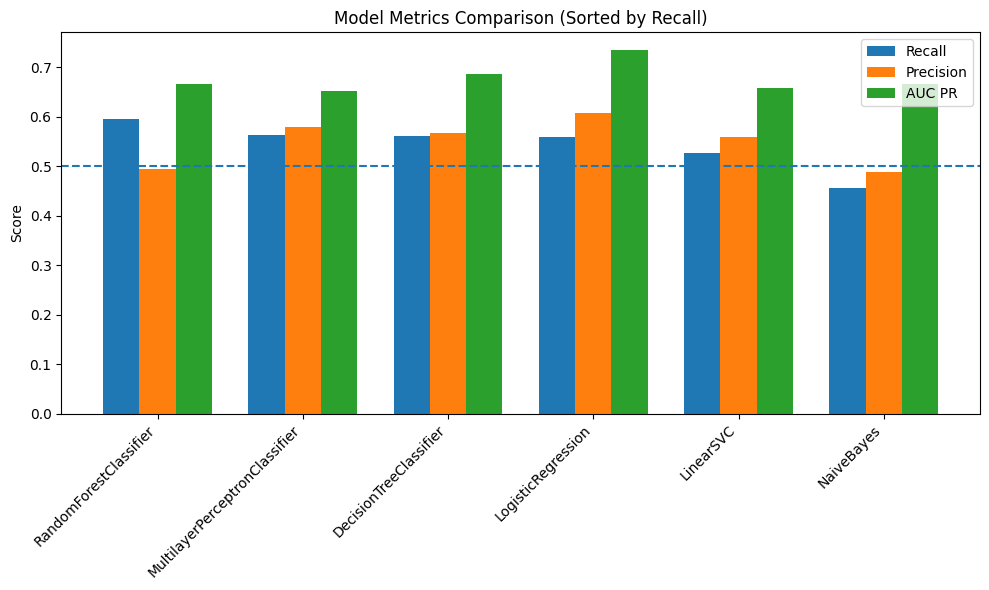

In [ ]:
rows = df_metrics.select("model", "recall",  "auc_pr", "precision").collect()

models = [row["model"] for row in rows]
recall = [row["recall"] for row in rows]
precision = [row["precision"] for row in rows]
auc_pr = [row["auc_pr"] for row in rows]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, recall, width, label="Recall")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, auc_pr, width, label="AUC PR")

plt.axhline(0.5, linestyle="--")
plt.text(-0.5, 0.51, "random guessing")

plt.ylabel("Score")
plt.title("Model Metrics Comparison (Sorted by Recall)")
plt.xticks(x, models, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Based on the baseline validation results, the Random Forest Classifier was selected for hyperparameter tuning because it produced the highest recall among all evaluated models. As recall was treated as the primary metric, this model was considered the most suitable candidate for further optimization.

Hyperparameter tuning was performed to improve the model's sensitivity while maintaining reasonable overall predictive performance. The parameters explored included the number of trees, maximum depth, and minimum instances per node, as these are key factors influencing the behavior and complexity of a Random Forest model. The tuned configurations were assessed on the validation split, and only the final selected model was later evaluated on the test split.

Initial attempts to run full cross-validation resulted in Java heap memory failures in the local environment due to the computational cost of repeatedly training the model across multiple parameter combinations and folds. To address this limitation, a VectorSlicer was introduced to retain only the top PCA-derived features before classification, reducing the feature space and making the workflow lighter to execute on the local laptop. This adjustment also allowed the implementation to demonstrate the use of a Spark ML pipeline and cross-validation setup in a practical way, while remaining feasible within the available system resources.


In [ ]:
# from pathlib import Path

# from pyspark.sql import functions as F


# def build_feature_engineering_table(spark, project_root=None):
#     if project_root is None:
#         project_root = Path("").resolve()

#     input_dir = project_root / "data" / "processed" / "all_csv_agg_ALLLL"

#     df = (
#         spark.read
#         .option("header", True)
#         .option("inferSchema", True)
#         .csv(str(input_dir))
#     )

#     electrodes = ["Fz", "FCz", "Cz", "FC3", "FC4", "C3", "C4", "CP3", "CP4"]
#     erp_windows = ["B0", "B1", "N100", "P200"]
#     stats_suffix = "avg"

#     regional_groups = {
#         "frontal": ["Fz", "FCz"],
#         "central": ["Cz", "C3", "C4"],
#         "frontocentral": ["FC3", "FC4", "FCz"],
#         "parietal": ["CP3", "CP4"],
#         "left": ["FC3", "C3", "CP3"],
#         "right": ["FC4", "C4", "CP4"],
#         "global": electrodes,
#     }

#     asymmetry_pairs = {
#         "fc": ("FC3", "FC4"),
#         "c": ("C3", "C4"),
#         "cp": ("CP3", "CP4"),
#     }

#     active_condition = 1
#     passive_condition = 2

#     def mean_expr(cols):
#         return sum(F.col(c) for c in cols) / F.lit(len(cols))

#     def existing_cols(cols, df_columns):
#         return [c for c in cols if c in df_columns]

#     def add_regional_features(df_in, groups, windows, stat_suffix):
#         df_columns = set(df_in.columns)
#         out = df_in

#         for window in windows:
#             for region_name, region_electrodes in groups.items():
#                 cols = [f"{elec}_{window}_{stat_suffix}" for elec in region_electrodes]
#                 cols = existing_cols(cols, df_columns)

#                 if cols:
#                     out = out.withColumn(
#                         f"{region_name}_{window}_{stat_suffix}",
#                         mean_expr(cols)
#                     )

#         return out

#     def add_baseline_adjusted_features(df_in, target_windows, baseline_window, stat_suffix):
#         df_columns = set(df_in.columns)
#         out = df_in

#         for elec in electrodes:
#             base_col = f"{elec}_{baseline_window}_{stat_suffix}"
#             if base_col not in df_columns:
#                 continue

#             for target_window in target_windows:
#                 target_col = f"{elec}_{target_window}_{stat_suffix}"
#                 if target_col in df_columns:
#                     out = out.withColumn(
#                         f"{elec}_{target_window}_adj_{baseline_window}_{stat_suffix}",
#                         F.col(target_col) - F.col(base_col)
#                     )

#         for region_name in regional_groups.keys():
#             base_col = f"{region_name}_{baseline_window}_{stat_suffix}"
#             if base_col not in out.columns:
#                 continue

#             for target_window in target_windows:
#                 target_col = f"{region_name}_{target_window}_{stat_suffix}"
#                 if target_col in out.columns:
#                     out = out.withColumn(
#                         f"{region_name}_{target_window}_adj_{baseline_window}_{stat_suffix}",
#                         F.col(target_col) - F.col(base_col)
#                     )

#         return out

#     def add_n100_p200_relationship_features(df_in, stat_suffix):
#         df_columns = set(df_in.columns)
#         out = df_in

#         for elec in electrodes:
#             n100_col = f"{elec}_N100_{stat_suffix}"
#             p200_col = f"{elec}_P200_{stat_suffix}"
#             if n100_col in df_columns and p200_col in df_columns:
#                 out = out.withColumn(
#                     f"{elec}_N100_P200_diff_{stat_suffix}",
#                     F.col(n100_col) - F.col(p200_col)
#                 )

#         for region_name in regional_groups.keys():
#             n100_col = f"{region_name}_N100_{stat_suffix}"
#             p200_col = f"{region_name}_P200_{stat_suffix}"
#             if n100_col in out.columns and p200_col in out.columns:
#                 out = out.withColumn(
#                     f"{region_name}_N100_P200_diff_{stat_suffix}",
#                     F.col(n100_col) - F.col(p200_col)
#                 )

#         return out

#     def add_asymmetry_features(df_in, windows, stat_suffix):
#         df_columns = set(df_in.columns)
#         out = df_in

#         for window in windows:
#             for pair_name, (left_elec, right_elec) in asymmetry_pairs.items():
#                 left_col = f"{left_elec}_{window}_{stat_suffix}"
#                 right_col = f"{right_elec}_{window}_{stat_suffix}"

#                 if left_col in df_columns and right_col in df_columns:
#                     out = out.withColumn(
#                         f"{pair_name}_{window}_asym_{stat_suffix}",
#                         F.col(left_col) - F.col(right_col)
#                     )

#         for hemi_window in ["N100", "P200", "B0", "B1"]:
#             left_col = f"left_{hemi_window}_{stat_suffix}"
#             right_col = f"right_{hemi_window}_{stat_suffix}"
#             if left_col in out.columns and right_col in out.columns:
#                 out = out.withColumn(
#                     f"hemisphere_{hemi_window}_asym_{stat_suffix}",
#                     F.col(left_col) - F.col(right_col)
#                 )

#         return out

#     trial_features_df = df
#     trial_features_df = add_regional_features(
#         df_in=trial_features_df,
#         groups=regional_groups,
#         windows=erp_windows,
#         stat_suffix=stats_suffix,
#     )
#     trial_features_df = add_baseline_adjusted_features(
#         df_in=trial_features_df,
#         target_windows=["N100", "P200"],
#         baseline_window="B0",
#         stat_suffix=stats_suffix,
#     )
#     trial_features_df = add_n100_p200_relationship_features(
#         df_in=trial_features_df,
#         stat_suffix=stats_suffix,
#     )
#     trial_features_df = add_asymmetry_features(
#         df_in=trial_features_df,
#         windows=erp_windows,
#         stat_suffix=stats_suffix,
#     )

#     subject_condition_agg_exprs = []
#     for elec in electrodes:
#         for window in ["N100", "P200", "B0", "B1"]:
#             col_name = f"{elec}_{window}_{stats_suffix}"
#             if col_name in trial_features_df.columns:
#                 subject_condition_agg_exprs.append(
#                     F.avg(F.col(col_name)).alias(col_name)
#                 )

#     subject_condition_means_df = (
#         trial_features_df
#         .groupBy("subject", "condition")
#         .agg(*subject_condition_agg_exprs)
#     )

#     suppression_join_base = (
#         subject_condition_means_df
#         .select(
#             "subject",
#             "condition",
#             *[c for c in subject_condition_means_df.columns if c.endswith("_N100_avg")]
#         )
#     )

#     active_df = (
#         suppression_join_base
#         .filter(F.col("condition") == active_condition)
#         .drop("condition")
#     )

#     passive_df = (
#         suppression_join_base
#         .filter(F.col("condition") == passive_condition)
#         .drop("condition")
#     )

#     suppression_df = active_df.alias("a").join(
#         passive_df.alias("p"),
#         on="subject",
#         how="inner"
#     )

#     for elec in electrodes:
#         suppression_df = suppression_df.withColumn(
#             f"{elec}_N100_supp_avg",
#             F.col(f"p.{elec}_N100_avg") - F.col(f"a.{elec}_N100_avg")
#         )

#     suppression_df = suppression_df.select(
#         "subject",
#         *[f"{elec}_N100_supp_avg" for elec in electrodes]
#     )

#     suppression_df = add_regional_features(
#         df_in=suppression_df,
#         groups=regional_groups,
#         windows=["N100_supp"],
#         stat_suffix="avg",
#     )

#     variability_target_cols = []
#     for elec in electrodes:
#         col_name = f"{elec}_N100_{stats_suffix}"
#         if col_name in trial_features_df.columns:
#             variability_target_cols.append(col_name)

#     variability_exprs = []
#     for col_name in variability_target_cols:
#         variability_exprs.extend([
#             F.stddev(F.col(col_name)).alias(f"{col_name}_trial_std"),
#             (F.max(F.col(col_name)) - F.min(F.col(col_name))).alias(f"{col_name}_trial_range"),
#             (
#                 F.stddev(F.col(col_name)) / (F.abs(F.avg(F.col(col_name))) + F.lit(1e-6))
#             ).alias(f"{col_name}_trial_cv")
#         ])

#     subject_variability_df = (
#         trial_features_df
#         .groupBy("subject", "condition")
#         .agg(*variability_exprs)
#     )

#     subject_variability_agg_exprs = []
#     for col_name in subject_variability_df.columns:
#         if col_name not in {"subject", "condition"}:
#             subject_variability_agg_exprs.append(
#                 F.avg(F.col(col_name)).alias(col_name)
#             )

#     subject_variability_final_df = (
#         subject_variability_df
#         .groupBy("subject")
#         .agg(*subject_variability_agg_exprs)
#     )

#     subject_features_df = (
#         suppression_df
#         .join(subject_variability_final_df, on="subject", how="outer")
#     )

#     final_features_df = (
#         trial_features_df
#         .join(subject_features_df, on="subject", how="left")
#     )

#     windows = ["B0", "B1", "N100", "P200"]
#     id_cols = ["subject", "trial", "condition"]

#     raw_keep_cols = [
#         f"{elec}_{window}_avg"
#         for elec in electrodes
#         for window in windows
#         if f"{elec}_{window}_avg" in final_features_df.columns
#     ]

#     engineered_prefixes = (
#         "frontal_",
#         "central_",
#         "frontocentral_",
#         "parietal_",
#         "left_",
#         "right_",
#         "global_",
#     )

#     engineered_contains = (
#         "_adj_B0_",
#         "_N100_P200_diff_",
#         "_asym_",
#         "_supp_",
#         "_trial_std",
#         "_trial_range",
#         "_trial_cv",
#     )

#     engineered_cols = [
#         c for c in final_features_df.columns
#         if (
#             c.startswith(engineered_prefixes)
#             or any(token in c for token in engineered_contains)
#         )
#     ]

#     final_modeling_cols = []
#     seen = set()

#     for c in id_cols + raw_keep_cols + engineered_cols:
#         if c in final_features_df.columns and c not in seen:
#             final_modeling_cols.append(c)
#             seen.add(c)

#     final_modeling_df = final_features_df.select(*final_modeling_cols)
#     return final_modeling_df


# final_modeling_df = build_feature_engineering_table(spark)

'''
This full pipeline couldnt run because of memory errors 
'''


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorSlicer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

positive_label = 1.0
top_k = 128

slicer = VectorSlicer(
    inputCol="pcaFeatures",
    outputCol="rfFeatures",
    indices=list(range(top_k))
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="rfFeatures",
    seed=4202,
    featureSubsetStrategy="sqrt"
)

rf_pipeline = Pipeline(stages=[slicer, rf])

rf_param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 50, 100,])
    .addGrid(rf.maxDepth, [5, 10, 20])
    .addGrid(rf.minInstancesPerNode, [1])
    .build()
)

# optimize recall for the positive class
rf_cv_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="recallByLabel",
    metricLabel=positive_label
)

rf_crossval = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=rf_cv_evaluator,
    numFolds=5
)

rf_cv_model = rf_crossval.fit(train_df)
rf_cv_predictions = rf_cv_model.transform(val_df)

rf_cv_metrics = evaluate_predictions(
    rf_cv_predictions,
    "Pipeline(VectorSlicer -> RandomForestCV)"
)

best_rf = rf_cv_model.bestModel.stages[-1]
print("Best numTrees:", best_rf.getNumTrees)
print("Best maxDepth:", best_rf.getOrDefault("maxDepth"))
print("Best minInstancesPerNode:", best_rf.getOrDefault("minInstancesPerNode"))


Pipeline(VectorSlicer -> RandomForestCV) Metrics:
- Recall: 0.5876 (Primary Metric)
- Area Under PR: 0.6984
- Area Under ROC: 0.6984
- F1 Score: 0.4840
- Accuracy: 0.5876
- Precision: 0.4722

Best numTrees: 100
Best maxDepth: 5
Best minInstancesPerNode: 1


The cross-validated Random Forest pipeline achieved a validation recall of approximately 0.59, which is slightly lower than the baseline Random Forest validation recall of approximately 0.59. This suggests that, under the reduced feature-space and lightweight tuning setup, cross-validation did not improve validation performance. The result is likely influenced by the limited hyperparameter search space and the PCA-based dimensionality reduction to 128 features, which may have removed informative signals while helping the workflow remain feasible on the local machine.

## Error Analysis on Training and Final Test Sets

After model selection and validation, error analysis was performed on both the training set and the final held-out test set to better understand how well the selected Random Forest model generalizes. Examining the training set helps identify whether the model has learned the patterns in the data effectively, while the final test set provides an unbiased estimate of performance on unseen subjects. Comparing errors across these two splits is useful for detecting issues such as overfitting, underfitting, class imbalance, or systematic misclassification. This provides a clearer interpretation of model performance and helps determine whether the model is reliable for the classification task.

In [26]:
rf_train_predictions = rfFitted.transform(train_df)
rf_train_metrics = evaluate_predictions( rf_train_predictions, "RandomForestClassifier [Train]")

rf_test_predictions = rfFitted.transform(test_df)
rf_test_metrics = evaluate_predictions( rf_test_predictions, "RandomForestClassifier [Test]")

rf_cv_test_predictions = rf_cv_model.transform(test_df)
rf_cv_test_metrics = evaluate_predictions( rf_cv_test_predictions, "RandomForestClassifier [CV Test]")



RandomForestClassifier [Train] Metrics:
- Recall: 0.7044 (Primary Metric)
- Area Under PR: 0.9092
- Area Under ROC: 0.9092
- F1 Score: 0.6498
- Accuracy: 0.7044
- Precision: 0.7784

RandomForestClassifier [Test] Metrics:
- Recall: 0.4954 (Primary Metric)
- Area Under PR: 0.5086
- Area Under ROC: 0.5086
- F1 Score: 0.3906
- Accuracy: 0.4954
- Precision: 0.3498

RandomForestClassifier [CV Test] Metrics:
- Recall: 0.4592 (Primary Metric)
- Area Under PR: 0.4924
- Area Under ROC: 0.4924
- F1 Score: 0.3747
- Accuracy: 0.4592
- Precision: 0.3364



On the final evaluation, the selected Random Forest model achieved a training recall of approximately 0.70 and a test recall of approximately 0.50, showing a noticeable drop in sensitivity on unseen subjects. ROC AUC and PR AUC also decreased substantially from about 0.91 on the training set to about 0.51 on the test set. This pattern suggests that the model is **overfitting**, since it captures structure in the training data that does not transfer as effectively to the held-out test split. The decrease in precision on the test set further indicates an increase in false positive predictions during final evaluation.

In [7]:
# spark.stop()